In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

c:\Users\Acer3\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Acer3\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Descrição do conjunto de dados

Neste notebook, utilizaremos um conjunto de dados disponibilizado no desafio de *machine learning* promovido pela **SEG (Society of Exploration Geophysicists)** em 2016. O desafio pode ser encontrado no repositório oficial: <a href="https://github.com/seg/2016-ml-contest">SEG 2016 Machine Learning Contest</a>.

O objetivo do problema é realizar a **classificação de fácies litológicas** a partir de dados de perfis de poço. Em outras palavras, queremos treinar modelos de aprendizado de máquina capazes de reconhecer diferentes tipos de rochas ou associações litológicas com base em atributos medidos ao longo do poço.

A variável alvo do problema é a coluna **`Facies`**, que representa a classe litológica de cada amostra. Neste conjunto de dados, as fácies foram divididas em **9 classes**:

1. **Nonmarine sandstone**
2. **Nonmarine coarse siltstone**
3. **Nonmarine fine siltstone**
4. **Marine siltstone and shale**
5. **Mudstone (limestone)**
6. **Wackestone (limestone)**
7. **Dolomite**
8. **Packstone-grainstone (limestone)**
9. **Phylloid-algal bafflestone (limestone)**

Essas classes também possuem siglas, que facilitam a interpretação e a visualização dos resultados:

| Label | Sigla | Fácies adjacentes | Descrição |
|:----:|:-----:|:-----------------:|-----------|
| 1 | SS   | 2 | Nonmarine sandstone |
| 2 | CSiS | 1, 3 | Nonmarine coarse siltstone |
| 3 | FSiS | 2 | Nonmarine fine siltstone |
| 4 | SiSh | 5 | Marine siltstone and shale |
| 5 | MS   | 4, 6 | Mudstone (limestone) |
| 6 | WS   | 5, 7 | Wackestone (limestone) |
| 7 | D    | 6, 8 | Dolomite |
| 8 | PS   | 6, 7, 9 | Packstone-grainstone (limestone) |
| 9 | BS   | 7, 8 | Phylloid-algal bafflestone (limestone) |

### O que significa "fácies adjacentes"?

A coluna **fácies adjacentes** indica classes que são geologicamente próximas ou que podem ser mais facilmente confundidas entre si. Isso é importante porque, em muitos problemas reais de geologia e geofísica, a transição entre litologias não ocorre de forma abrupta. Em vez disso, pode haver mudanças graduais nas propriedades das rochas, tornando a classificação mais desafiadora.

### Por que esse dataset é interessante para IA aplicada à geofísica?

Este conjunto de dados é bastante útil em uma disciplina de **Inteligência Artificial aplicada à Geofísica** porque permite trabalhar, ao mesmo tempo, conceitos de:

- **classificação supervisionada**;
- **problemas multiclasse**;
- **análise de dados de poço**;
- **interpretação geológica assistida por algoritmos**;
- **avaliação de desempenho de modelos de machine learning**.

Além disso, trata-se de um problema realista, em que diferentes classes podem apresentar comportamento semelhante nos atributos medidos, o que torna a tarefa de classificação mais complexa e mais próxima de aplicações reais em subsuperfície.

Ao longo desta aula, utilizaremos esse dataset para explorar técnicas de aprendizado de máquina voltadas à **classificação de fácies**, discutindo tanto os aspectos computacionais quanto a interpretação geofísica dos resultados.

In [2]:
# Funções
def plot_well_logs(
    df,
    well_name,
    cols,
    depth_col='Depth',
    well_col='Well Name',
    depth_unit='m',
    x_units=None,
    figsize=(10, 12),
    title=None,
    sharey=True
):
    """
    Plota curvas de perfis para um poço específico.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados dos perfis.
    well_name : str
        Nome do poço a ser plotado.
    cols : list of str
        Lista com os nomes das colunas a serem exibidas.
    depth_col : str, default='Depth'
        Nome da coluna de profundidade.
    well_col : str, default='Well Name'
        Nome da coluna que identifica o poço.
    depth_unit : str, default='m'
        Unidade da profundidade.
    x_units : dict or None, default=None
        Dicionário com as unidades de cada curva.
        Exemplo: {'GR': 'API', 'PHIND': 'v/v'}
    figsize : tuple, default=(10, 12)
        Tamanho da figura.
    title : str or None, default=None
        Título geral da figura.
    sharey : bool, default=True
        Se True, compartilha o eixo y entre os subplots.

    Retorna
    -------
    fig, axes
        Objetos da figura e dos eixos.
    """
    df_well = df[df[well_col] == well_name]

    fig, axes = plt.subplots(
        ncols=len(cols),
        figsize=figsize,
        sharey=sharey
    )

    if len(cols) == 1:
        axes = [axes]

    if x_units is None:
        x_units = {}

    for col, ax in zip(cols, axes):
        ax.plot(df_well[col], df_well[depth_col])
        ax.invert_yaxis()
        ax.grid(True)

        ax.set_title(col)

        unit = x_units.get(col, '')
        ax.set_xlabel(unit)

    axes[0].set_ylabel(f'{depth_col} ({depth_unit})')

    if title is None:
        title = f'Poço: {well_name}'

    fig.suptitle(title, fontsize=16, y=1.02)
    fig.tight_layout()

    return fig, axes

##### Carregando o dataset

In [3]:
# Carregando o dataset facies_vector.csv
df = pd.read_csv('..\\..\\data\\csv\\facies_vectors.csv')

# Verificando os tipos de variáveis e a presença de valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4149 entries, 0 to 4148
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Facies     4149 non-null   int64  
 1   Formation  4149 non-null   str    
 2   Well Name  4149 non-null   str    
 3   Depth      4149 non-null   float64
 4   GR         4149 non-null   float64
 5   ILD_log10  4149 non-null   float64
 6   DeltaPHI   4149 non-null   float64
 7   PHIND      4149 non-null   float64
 8   PE         3232 non-null   float64
 9   NM_M       4149 non-null   int64  
 10  RELPOS     4149 non-null   float64
dtypes: float64(7), int64(2), str(2)
memory usage: 413.0 KB


In [4]:
#Criando uma coluna com os labels (caracteres) das facies
def litologia(facies):
    if facies == 1: return 'Nonmarine sandstone'
    if facies == 2: return 'Nonmarine coarse siltstone'
    if facies == 3: return 'Nonmarine fine siltstone'
    if facies == 4: return 'Marine siltstone and shale'
    if facies == 5: return 'Mudstone (limestone)'
    if facies == 6: return 'Wackestone (limestone)'
    if facies == 7: return 'Dolomite'
    if facies == 8: return 'Packstone-grainstone (limestone)'
    if facies == 9:
        return 'Phylloid-algal bafflestone (limestone)'
    

df['Labels_char'] = df.Facies.apply(litologia)
df.head()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,Labels_char
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,1,1.000,Nonmarine fine siltstone
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,1,0.979,Nonmarine fine siltstone
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,1,0.957,Nonmarine fine siltstone
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,1,0.936,Nonmarine fine siltstone
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,1,0.915,Nonmarine fine siltstone


(<Figure size 1000x1200 with 5 Axes>,
 array([<Axes: title={'center': 'GR'}, xlabel='API', ylabel='Depth (m)'>,
        <Axes: title={'center': 'ILD_log10'}, xlabel='log10(ohm.m)'>,
        <Axes: title={'center': 'DeltaPHI'}, xlabel='v/v'>,
        <Axes: title={'center': 'PHIND'}, xlabel='v/v'>,
        <Axes: title={'center': 'PE'}, xlabel='b/e'>], dtype=object))

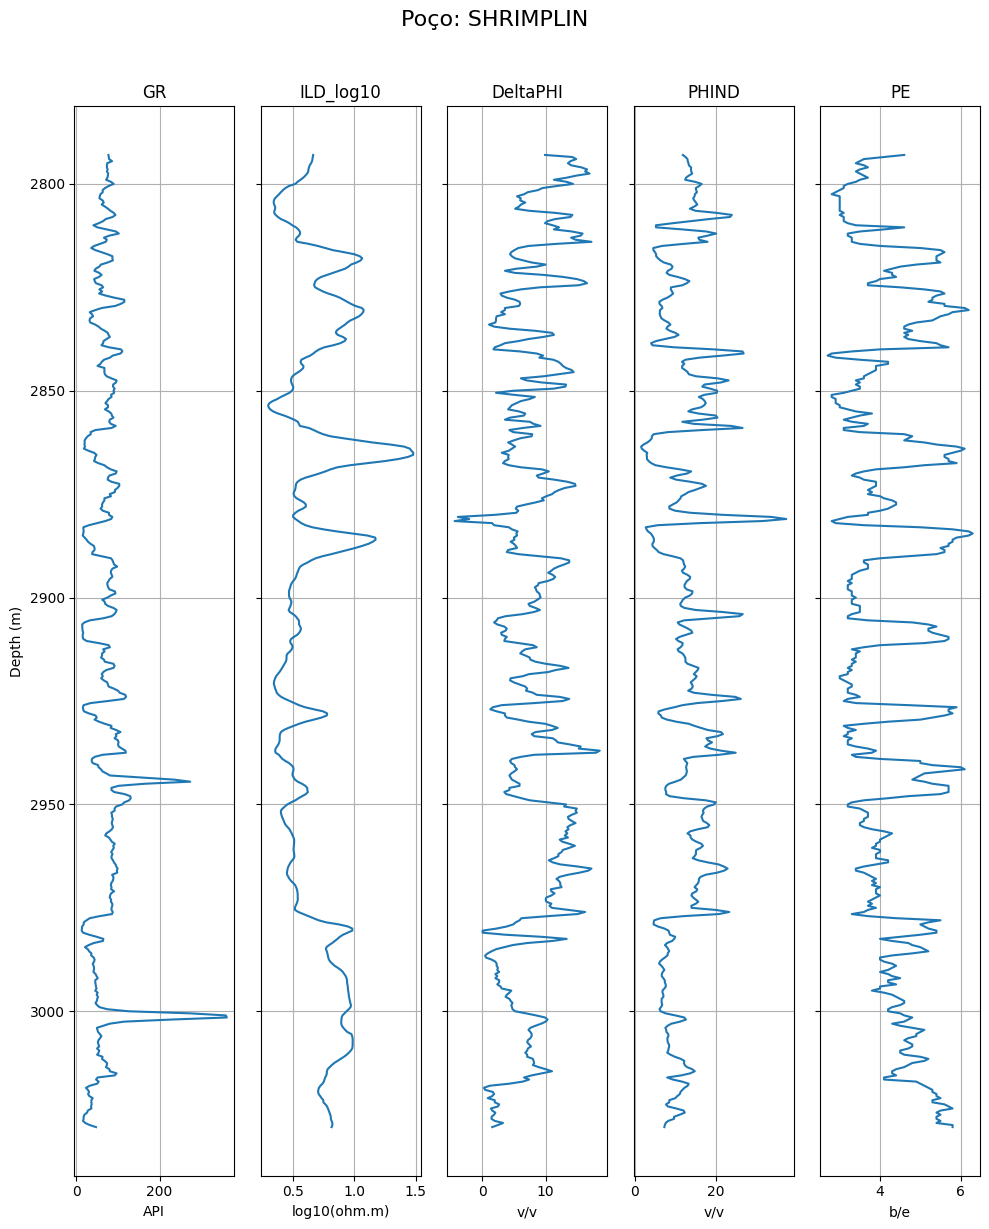

In [5]:
cols = ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE']

units = {
    'GR': 'API',
    'ILD_log10': 'log10(ohm.m)',
    'DeltaPHI': 'v/v',
    'PHIND': 'v/v',
    'PE': 'b/e'
}

plot_well_logs(
    df=df,
    well_name='SHRIMPLIN',
    cols=cols,
    depth_unit='m',
    x_units=units
)

In [6]:
# Verificando quais poços tem medidas ausentes
df.isna().groupby(df['Well Name']).sum()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,Labels_char
Well Name,,,,,,,,,,,,
ALEXANDER D,0,0,0,0,0,0,0,0,466,0,0,0
CHURCHMAN BIBLE,0,0,0,0,0,0,0,0,0,0,0,0
CROSS H CATTLE,0,0,0,0,0,0,0,0,0,0,0,0
KIMZEY A,0,0,0,0,0,0,0,0,439,0,0,0
LUKE G U,0,0,0,0,0,0,0,0,0,0,0,0
NEWBY,0,0,0,0,0,0,0,0,0,0,0,0
NOLAN,0,0,0,0,0,0,0,0,0,0,0,0
Recruit F9,0,0,0,0,0,0,0,0,12,0,0,0
SHANKLE,0,0,0,0,0,0,0,0,0,0,0,0


In [7]:
# Plotando o número de ocorrências de cada litologia
df.groupby(['Well Name', 'Labels_char']).size().unstack(fill_value=0)

Labels_char,Dolomite,Marine siltstone and shale,Mudstone (limestone),Nonmarine coarse siltstone,Nonmarine fine siltstone,Nonmarine sandstone,Packstone-grainstone (limestone),Phylloid-algal bafflestone (limestone),Wackestone (limestone)
Well Name,,,,,,,,,
ALEXANDER D,16,44,26,117,91,0,98,5,69
CHURCHMAN BIBLE,34,13,30,56,51,8,75,50,87
CROSS H CATTLE,2,25,28,142,47,158,68,0,31
KIMZEY A,27,43,53,85,74,9,90,7,51
LUKE G U,20,35,2,117,129,0,74,0,84
NEWBY,16,58,28,98,80,0,56,31,96
NOLAN,4,28,47,118,68,4,116,0,30
Recruit F9,0,0,0,0,0,0,0,80,0
SHANKLE,17,7,19,89,117,89,40,0,71


<Axes: xlabel='count', ylabel='Labels_char'>

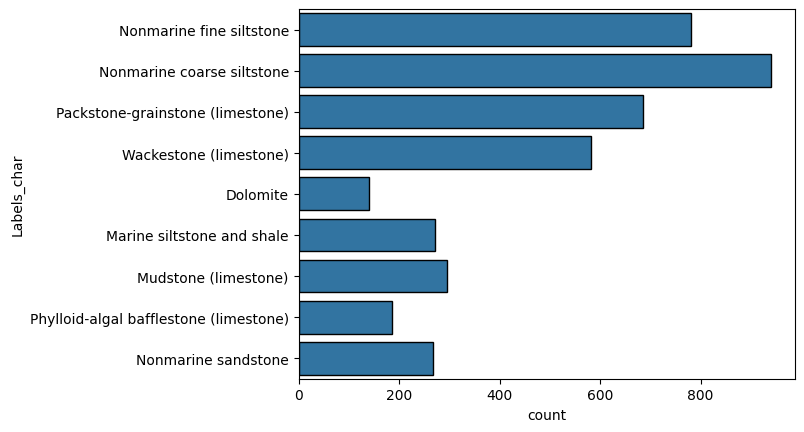

In [8]:
# Plotando o número de ocorrências de cada litologia
sns.countplot(data=df, y='Labels_char',edgecolor='black')

<Axes: xlabel='count', ylabel='Labels_char'>

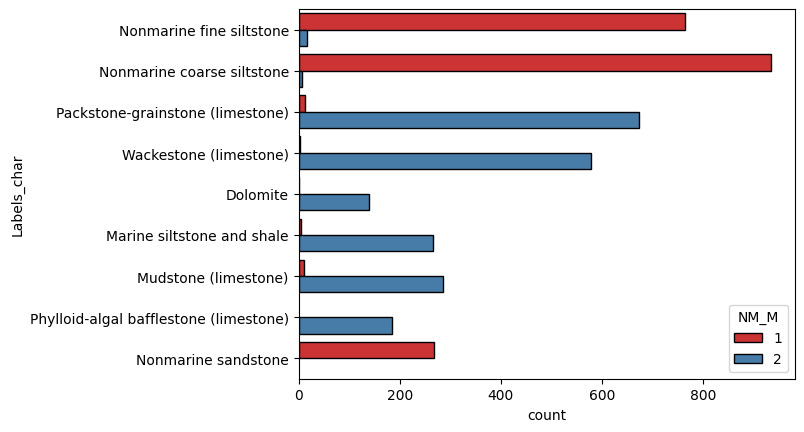

In [9]:
# Plotando a contagem de cada litologia e o ambiente de deposição

sns.countplot(data=df, y='Labels_char', hue='NM_M', palette='Set1',edgecolor='black')

In [10]:
# Corrigindo o rótulo numérico do ambiente de deposição

df.loc[df['Labels_char'].str.contains('Nonmarine', case=False, na=False), 'NM_M'] =1

df.loc[df['Labels_char'].str.contains('Marine', case=False, na=False), 'NM_M'] = 2

<Axes: xlabel='count', ylabel='Labels_char'>

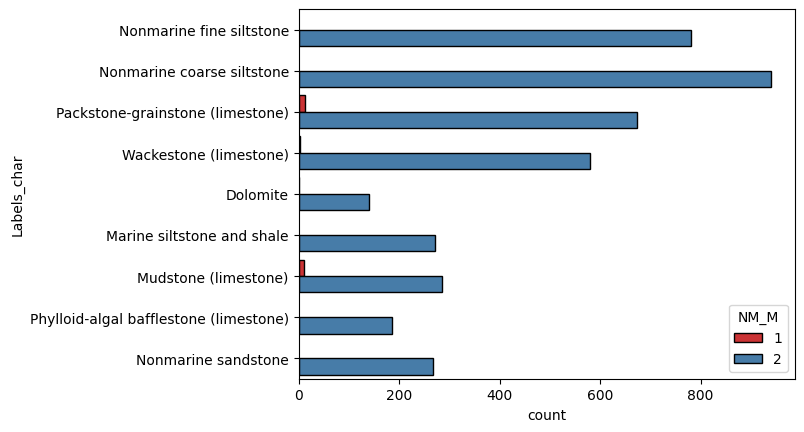

In [11]:
# Plotando a contagem de cada litologia e o ambiente de deposição para verificar se a correção foi feita corretamente

sns.countplot(data=df, y='Labels_char', hue='NM_M', palette='Set1',edgecolor='black')

#### Aumento de atributos (*data augmentation*)

Observe que a **porosidade neutrônica** e a **porosidade derivada da densidade** podem ser recuperadas a partir das variáveis `DeltaPHI` e `PHIND`.

As relações originais são dadas por:

$$
\Delta \phi = \phi_N - \phi_D
$$

$$
PHIND = \frac{\phi_N + \phi_D}{2}
$$

A partir dessas expressões, podemos isolar as duas porosidades:

$$
\phi_N = \frac{\Delta \phi + 2 \, PHIND}{2}
$$

$$
\phi_D = \frac{2 \, PHIND - \Delta \phi}{2}
$$

In [12]:
# Funções para calcular as curvas de porosidade efetiva e porosidade total a partir da curva de porosidade aparente (PHIND) e da curva de delta porosidade (DeltaPHI)

def phi_N(delta_phi,phi_nd):
    delta_phi = np.asarray(delta_phi); phi_nd = np.asarray(phi_nd)
    return (delta_phi+(2*phi_nd))/2

def phi_D(delta_phi,phi_nd):
    delta_phi = np.asarray(delta_phi); phi_nd = np.asarray(phi_nd)
    return (-delta_phi+(2*phi_nd))/2

In [13]:
#Calculando as porosidades densidade e neutrônica

df['PHID'] = phi_D(df.DeltaPHI,df.PHIND)
df['PHIN'] = phi_N(df.DeltaPHI,df.PHIND)

df.head()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,Labels_char,PHID,PHIN
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,2,1.000,Nonmarine fine siltstone,6.965,16.865
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,2,0.979,Nonmarine fine siltstone,5.465,19.665
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,2,0.957,Nonmarine fine siltstone,5.650,20.450
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,2,0.936,Nonmarine fine siltstone,6.165,20.065
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,2,0.915,Nonmarine fine siltstone,6.550,20.050


In [14]:
dict(enumerate(df['Formation'].astype('category').cat.categories))

{0: 'A1 LM',
 1: 'A1 SH',
 2: 'B1 LM',
 3: 'B1 SH',
 4: 'B2 LM',
 5: 'B2 SH',
 6: 'B3 LM',
 7: 'B3 SH',
 8: 'B4 LM',
 9: 'B4 SH',
 10: 'B5 LM',
 11: 'B5 SH',
 12: 'C LM',
 13: 'C SH'}

In [15]:
# Criando uma coluna numérica para as formações (Formation)
df['Formation_num'] = df['Formation'].astype('category').cat.codes

df.head()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,Labels_char,PHID,PHIN,Formation_num
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,2,1.000,Nonmarine fine siltstone,6.965,16.865,1
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,2,0.979,Nonmarine fine siltstone,5.465,19.665,1
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,2,0.957,Nonmarine fine siltstone,5.650,20.450,1
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,2,0.936,Nonmarine fine siltstone,6.165,20.065,1
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,2,0.915,Nonmarine fine siltstone,6.550,20.050,1


In [16]:
# Salvando um dicionário para mapear os códigos numéricos de volta para os nomes das formações
formation_mapping = dict(enumerate(df['Formation'].astype('category').cat.categories))
formation_mapping

{0: 'A1 LM',
 1: 'A1 SH',
 2: 'B1 LM',
 3: 'B1 SH',
 4: 'B2 LM',
 5: 'B2 SH',
 6: 'B3 LM',
 7: 'B3 SH',
 8: 'B4 LM',
 9: 'B4 SH',
 10: 'B5 LM',
 11: 'B5 SH',
 12: 'C LM',
 13: 'C SH'}

In [17]:
# Realizando o mesmo procedimento acima com o sklearn para verificar se o resultado é o mesmo

label_encoder = LabelEncoder()
df['Formation_num_sklearn'] = label_encoder.fit_transform(df['Formation'])
df.head()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,Labels_char,PHID,PHIN,Formation_num,Formation_num_sklearn
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,2,1.000,Nonmarine fine siltstone,6.965,16.865,1,1
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,2,0.979,Nonmarine fine siltstone,5.465,19.665,1,1
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,2,0.957,Nonmarine fine siltstone,5.650,20.450,1,1
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,2,0.936,Nonmarine fine siltstone,6.165,20.065,1,1
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,2,0.915,Nonmarine fine siltstone,6.550,20.050,1,1


In [18]:
# Deletando coluna para evitar repetição de informações
del(df['Formation_num_sklearn'])

In [19]:
df.head()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,Labels_char,PHID,PHIN,Formation_num
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,2,1.000,Nonmarine fine siltstone,6.965,16.865,1
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,2,0.979,Nonmarine fine siltstone,5.465,19.665,1
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,2,0.957,Nonmarine fine siltstone,5.650,20.450,1
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,2,0.936,Nonmarine fine siltstone,6.165,20.065,1
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,2,0.915,Nonmarine fine siltstone,6.550,20.050,1


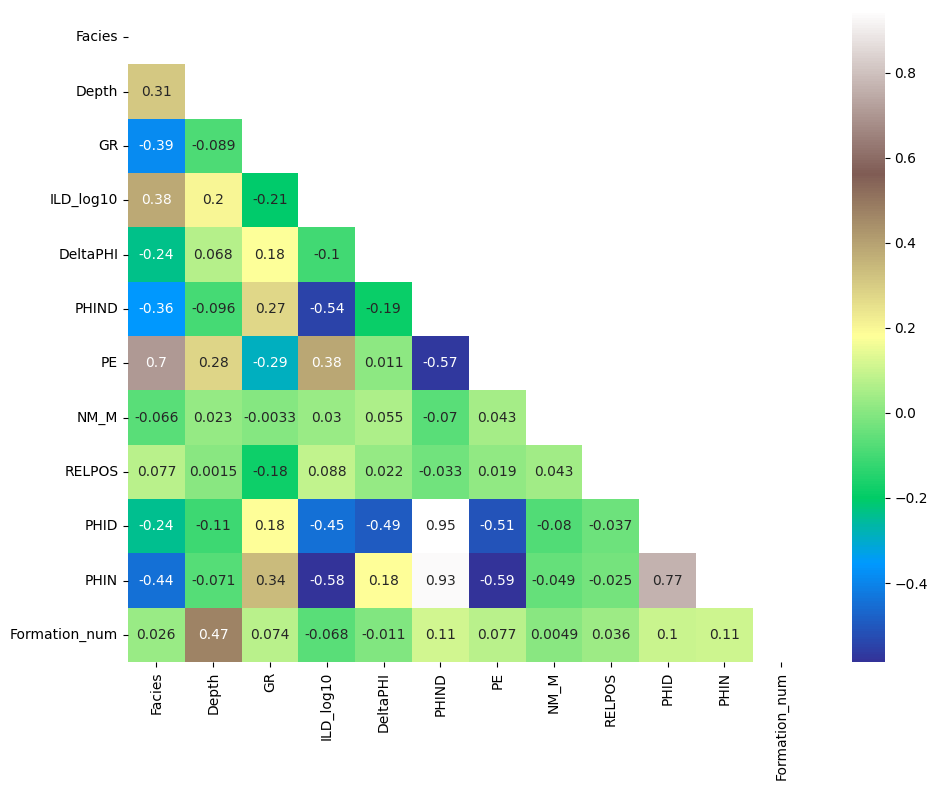

In [20]:
# Plotando a matriz de correlação entre as variáveis numéricas

corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='terrain',
    ax=ax
)

fig.tight_layout()

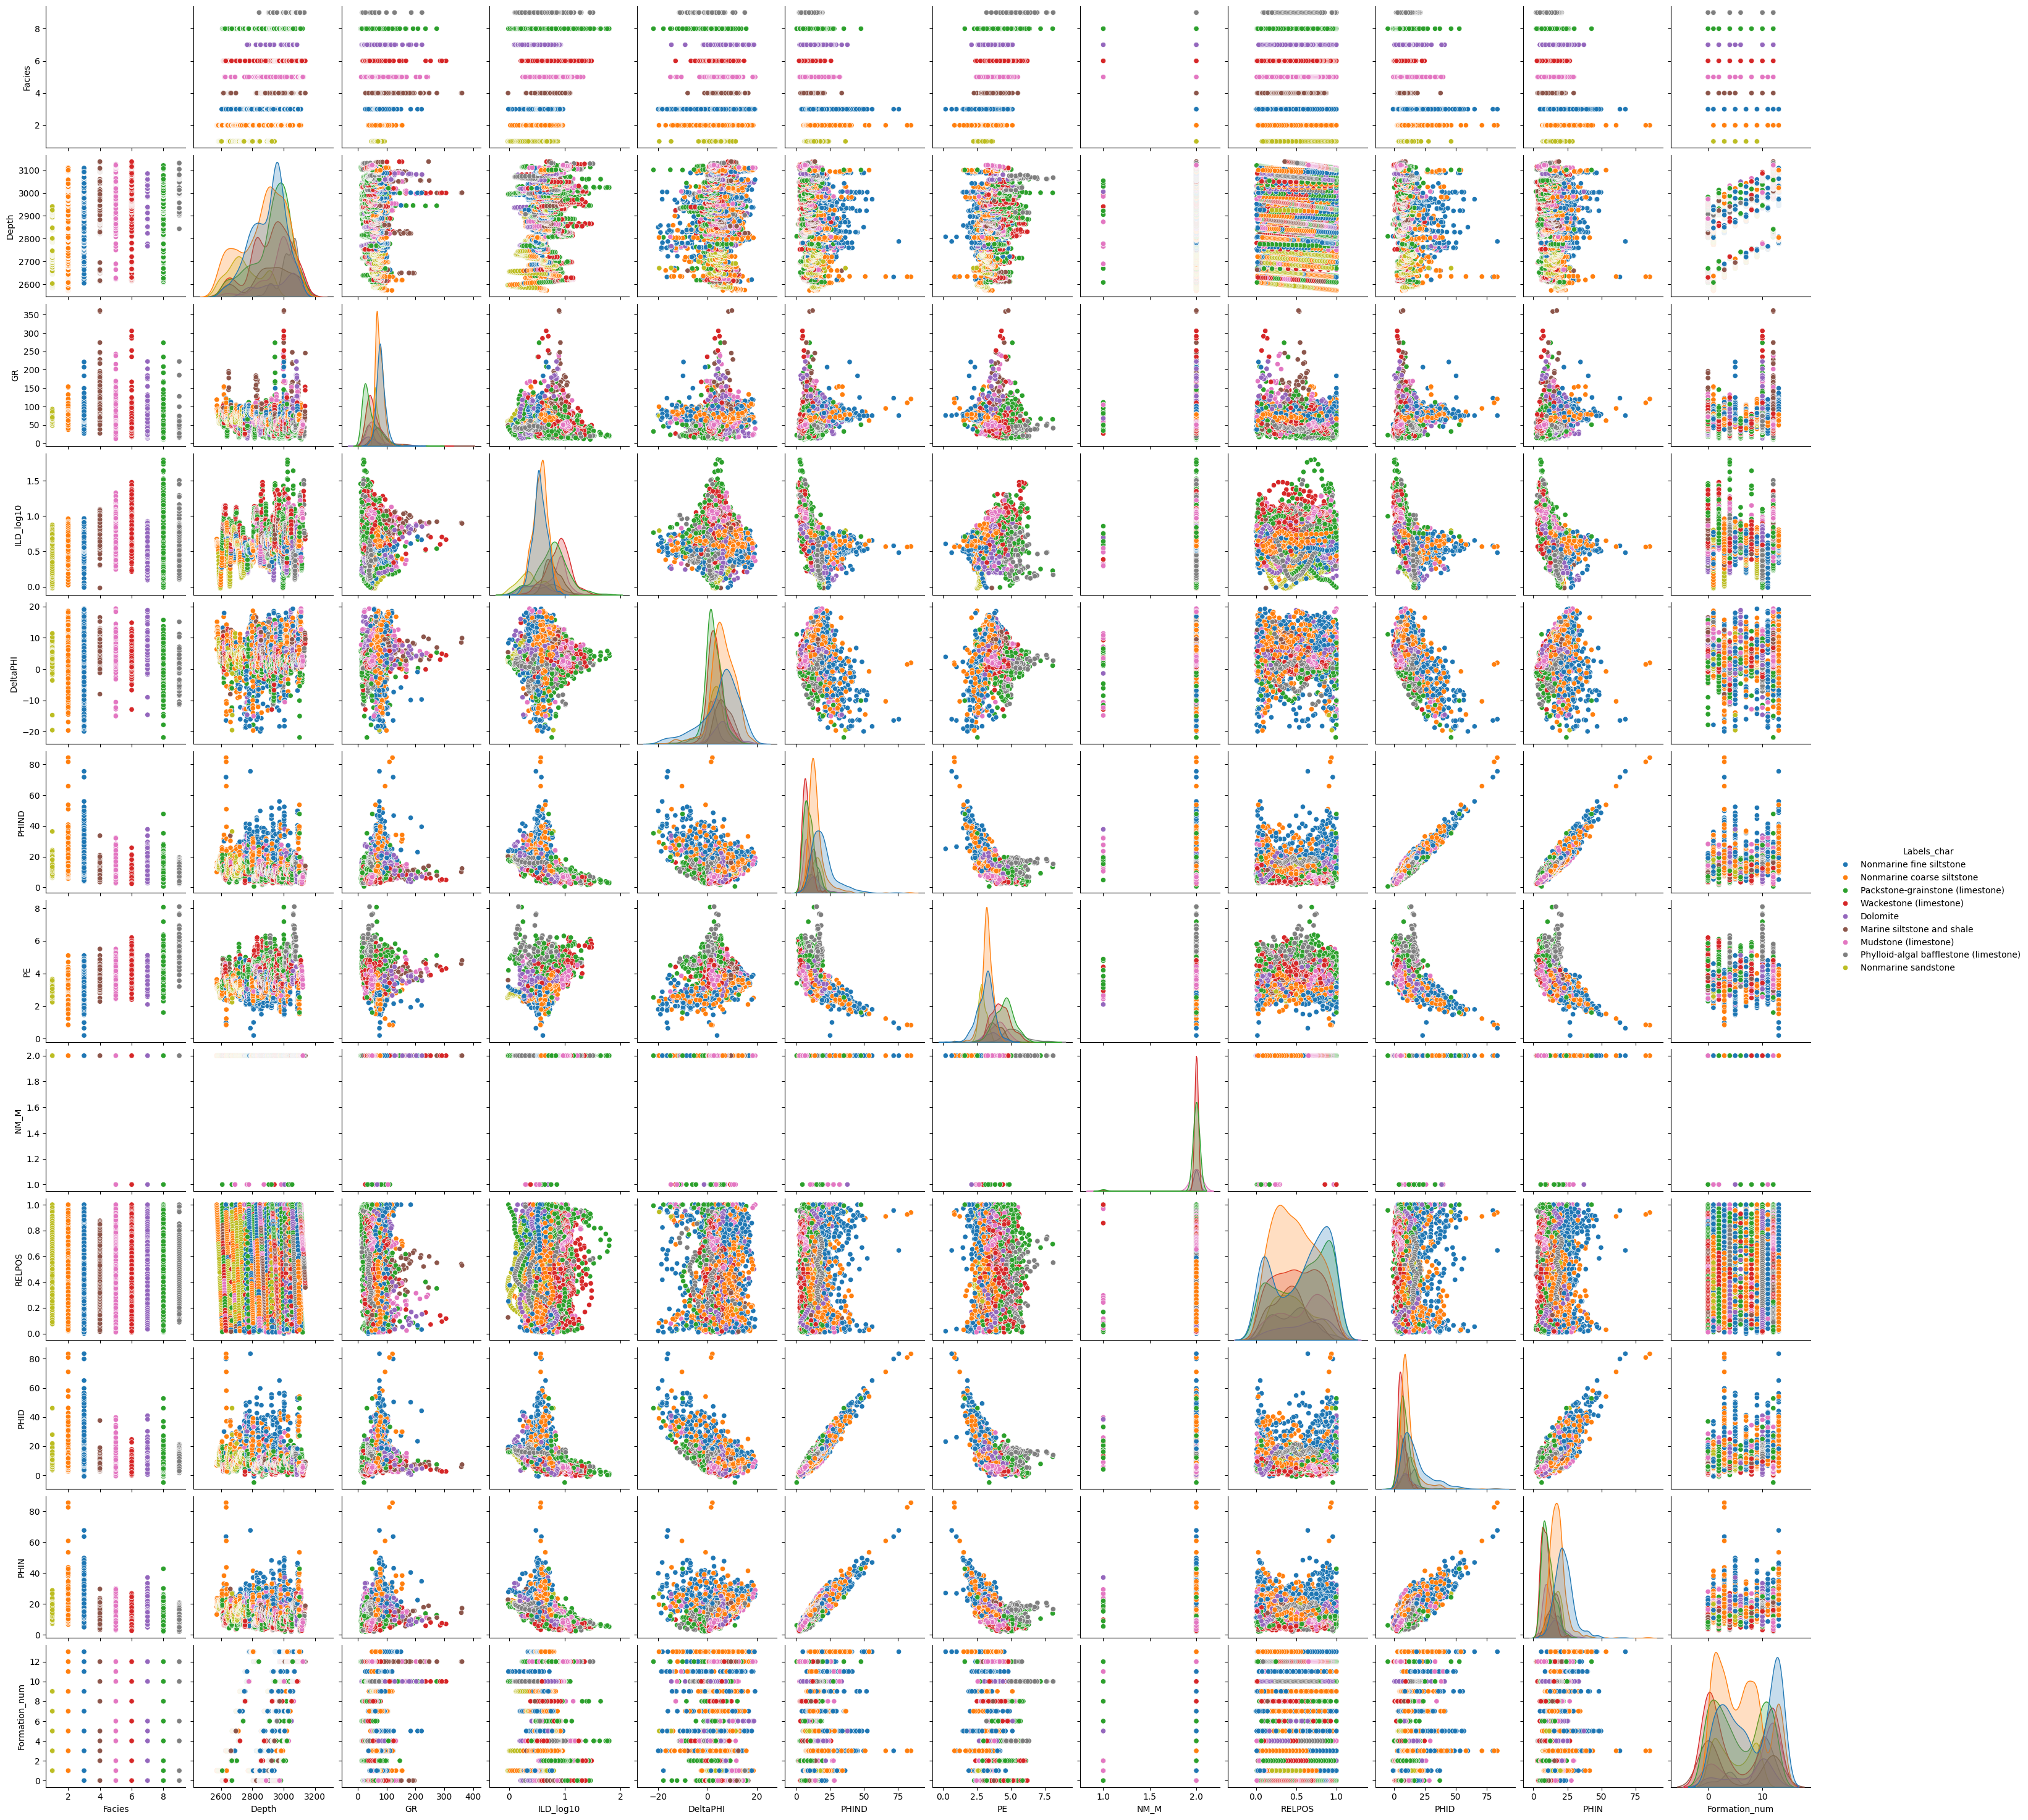

In [21]:
# Plotando o pairplot das variáveis numéricas para verificar a relação entre elas

numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist() + ['Labels_char']

sns.pairplot(df[numeric_columns],hue='Labels_char')

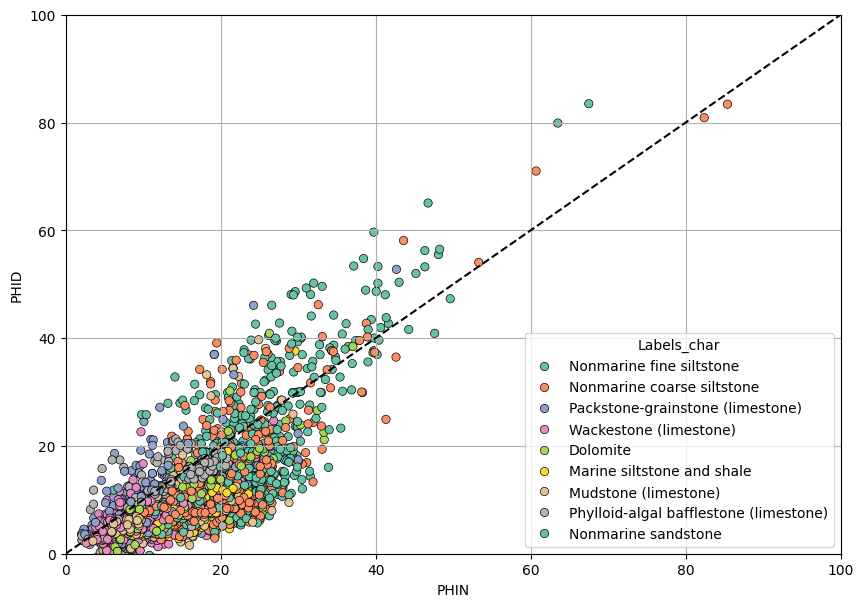

In [22]:
# Plotando PHIN vs PHID com o tipo de litologia como cor

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(data=df, x='PHIN', y='PHID', hue='Labels_char', palette='Set2', edgecolor='black')

#Plotando bisetriz para comparação entre PHIN e PHID

x = np.linspace(0, 100, 100)
ax.plot(x, x, color='black', linestyle='--')

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.grid(True)


#### Vamos realizar nossa primeira regressão linear para prever PE

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [24]:
df.select_dtypes(include=[np.number]).columns.tolist()

['Facies',
 'Depth',
 'GR',
 'ILD_log10',
 'DeltaPHI',
 'PHIND',
 'PE',
 'NM_M',
 'RELPOS',
 'PHID',
 'PHIN',
 'Formation_num']

In [25]:
cols = df.select_dtypes(include=[np.number]).columns.tolist()
cols.remove('Depth')
cols.remove('PE')

cols

['Facies',
 'GR',
 'ILD_log10',
 'DeltaPHI',
 'PHIND',
 'NM_M',
 'RELPOS',
 'PHID',
 'PHIN',
 'Formation_num']

In [26]:
# Separando os atributos (X) da variável alvo (y)
X = df[df['PE'].notna()][cols]
y = df[df['PE'].notna()]['PE']

In [27]:
Scaler = StandardScaler()
X_scaled = Scaler.fit_transform(X)

In [28]:
# Separando os dados em conjuntos de treino e teste

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [29]:
# Realizando o ajuste com todas as variáveis numéricas
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
# Testando o modelo no conjunto de teste
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.4f}')
print(f'R^2 Score: {r2:.4f}')

Mean Squared Error: 0.3348
R^2 Score: 0.6126


In [31]:
# Vamos otimizar o modelo testando todas as combinações possíveis de variáveis numéricas para encontrar a melhor combinação que maximize o R^2 Score e minimize o Mean Squared Error.

from sklearn.feature_selection import RFECV

selector = RFECV(estimator=LinearRegression(), step=1, cv=5, scoring='neg_root_mean_squared_error')

selector.fit(X_train, y_train)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearRegression()
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",5
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'neg_root_mean_squared_error'
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [36]:
# Realizando a predição na porção de dados onde PE era ausente

X_pred = df[cols]
X_pred_scaled_2 = Scaler.transform(X_pred)
y_pred_missing = model.predict(X_pred_scaled_2)

df['PE_reg_lin'] = y_pred_missing

# X_pred = df[df['PE'].isna()][cols]
# X_pred_scaled = Scaler.transform(X_pred)
# y_pred_missing = model.predict(X_pred_scaled)
#df.loc[df['PE'].isna(), 'PE'] = y_pred_missing



In [37]:
df['PE_reg_lin'] = model.predict(Scaler.transform(df[cols]))

In [38]:
df['Well Name'].unique().tolist()

['SHRIMPLIN',
 'ALEXANDER D',
 'SHANKLE',
 'LUKE G U',
 'KIMZEY A',
 'CROSS H CATTLE',
 'NOLAN',
 'Recruit F9',
 'NEWBY',
 'CHURCHMAN BIBLE']

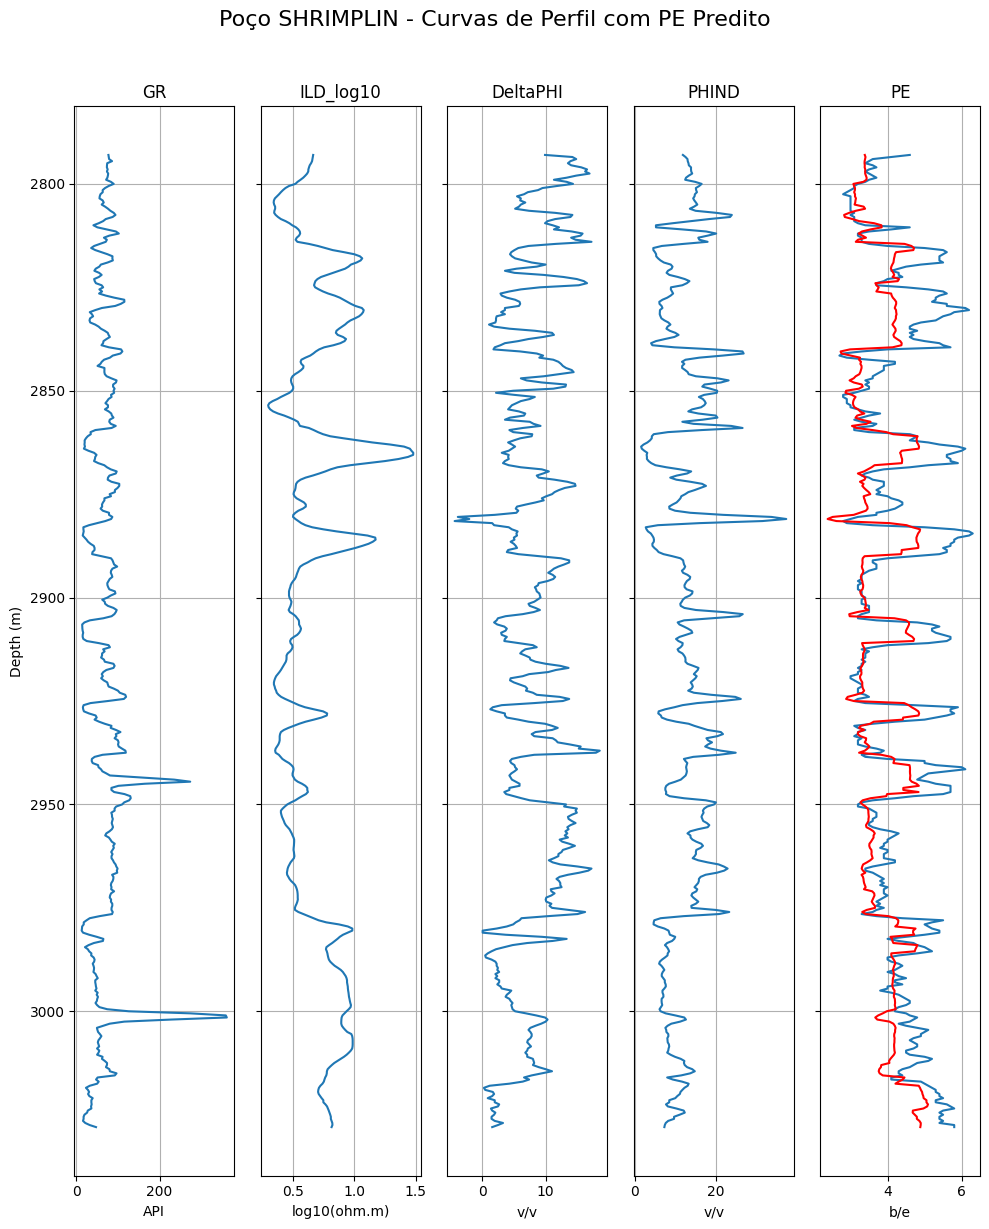

In [40]:
cols_plot = ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE']

well_name = 'SHRIMPLIN'

fig,axes = plot_well_logs(
    df=df,
    well_name=well_name,
    cols=cols_plot,
    depth_unit='m',
    x_units=units,
    title='Poço SHRIMPLIN - Curvas de Perfil com PE Predito'
)

axes[-1].plot(df[df['Well Name'] == well_name]['PE_reg_lin'], df[df['Well Name'] == well_name]['Depth'], color='red', label='PE Predito')

#### Exercício 

##### Faça a regressão utilizando o modelo KNN e compare os resultados com o modelo de regressão linear. Qual modelo apresentou melhor desempenho? Justifique sua resposta.